# Visual Question Answering (VQA) using CNN + LSTM (Transfer Learning with ResNet50)

This notebook builds a **Visual Question Answering (VQA)** system — given an image and a natural language question about that image, the model predicts an answer.

**Pipeline**
1. Image Feature Extraction: pretrained ResNet50 (transfer learning)
2. Question Encoding: Embedding layer + LSTM
3. Multimodal Fusion: concatenate image + question features, pass through Dense layers
4. Dataset: a small, self-contained synthetic shapes dataset (kept lightweight so the notebook stays beginner-friendly and fast to run)
5. Evaluation: accuracy, top-3 accuracy, sample predictions with images
6. Demo: interactive cell to test the model on a new image + question

**Tech Stack:** Python, TensorFlow/Keras, ResNet50, LSTM, Matplotlib, NumPy, Pandas, scikit-learn

**Note on the dataset:** Real-world VQA datasets like VQA v2 are tens of GBs and require heavy compute to train on, which isn't practical inside a CI/beginner notebook. To keep this notebook self-contained, fast, and easy to understand for beginners, we generate a small synthetic image+question+answer dataset on the fly (colored shapes with questions about their color/shape/identity). The same pipeline (ResNet50 + LSTM + fusion) applies directly to real VQA datasets — only the data-loading cell would need to change.

# Import Libraries

In [2]:
# core libraries
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw

# deep learning
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Input, Dense, Embedding, LSTM, Concatenate, Dropout
from tensorflow.keras.models import Model

# utils
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

# Generate a Small Synthetic VQA Dataset

In [3]:
# Each sample = (image, question, answer)
# Images contain one colored shape on a white background.
# Questions ask about the shape's color, type, or identity (yes/no).

IMG_SIZE = 64
SHAPES = ["circle", "square", "triangle"]
COLORS = {
    "red": (220, 40, 40),
    "green": (40, 180, 70),
    "blue": (40, 90, 220),
    "yellow": (230, 200, 30),
    "purple": (150, 50, 180),
}

def draw_shape(shape, color_name):
    img = Image.new("RGB", (IMG_SIZE, IMG_SIZE), (255, 255, 255))
    draw = ImageDraw.Draw(img)
    color = COLORS[color_name]
    m = 12
    x0, y0, x1, y1 = m, m, IMG_SIZE - m, IMG_SIZE - m
    if shape == "circle":
        draw.ellipse([x0, y0, x1, y1], fill=color)
    elif shape == "square":
        draw.rectangle([x0, y0, x1, y1], fill=color)
    else:  # triangle
        draw.polygon([(IMG_SIZE // 2, y0), (x0, y1), (x1, y1)], fill=color)
    return np.array(img)

def build_dataset(n_images=200):
    records = []
    for _ in range(n_images):
        shape = random.choice(SHAPES)
        color_name = random.choice(list(COLORS.keys()))
        img = draw_shape(shape, color_name)

        wrong_shape = random.choice(SHAPES)
        qas = [
            ("What shape is shown in the image?", shape),
            ("What color is the shape?", color_name),
            ("Is the shape a circle?", "yes" if shape == "circle" else "no"),
            (f"Is the shape {color_name}?", "yes"),
            (f"Is the shape a {wrong_shape}?", "yes" if wrong_shape == shape else "no"),
        ]
        for q, a in qas:
            records.append({"image": img, "question": q, "answer": a})
    return records

records = build_dataset(n_images=200)
print(f"Total (image, question, answer) samples generated = {len(records)}")

Total (image, question, answer) samples generated = 1000


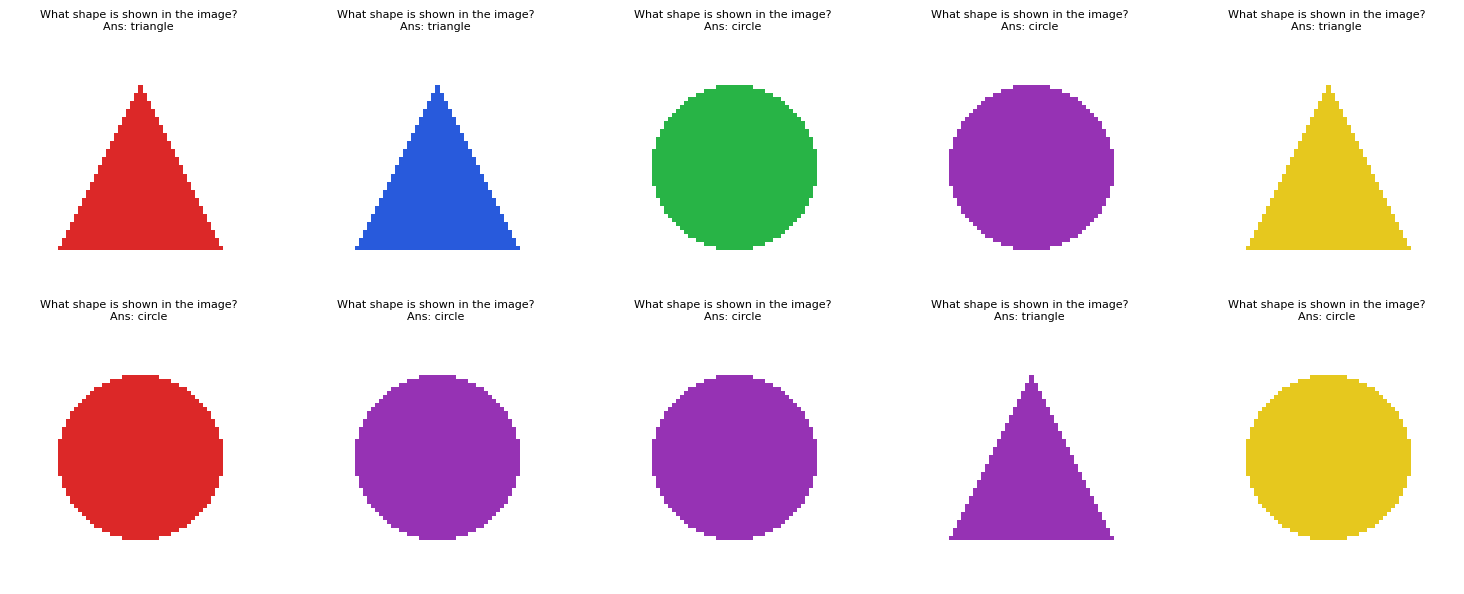

In [4]:
# Sample Images with their Question-Answer pairs

plt.figure(figsize=(15, 6))
for i in range(10):
    sample = records[i * 5]
    plt.subplot(2, 5, i + 1)
    plt.imshow(sample["image"])
    plt.title(f"{sample['question']}\nAns: {sample['answer']}", fontsize=8)
    plt.axis("off")
plt.tight_layout()
plt.show()

# Image Feature Extraction using Pretrained ResNet50 (Transfer Learning)

In [5]:
# We use ResNet50 pretrained on ImageNet as a frozen feature extractor.
# include_top=False + pooling='avg' gives us a single 2048-d feature vector per image.

images = np.array([r["image"] for r in records], dtype="float32")
images_preprocessed = preprocess_input(images.copy())

cnn = ResNet50(weights="imagenet", include_top=False, pooling="avg", input_shape=(IMG_SIZE, IMG_SIZE, 3))
cnn.trainable = False  # freeze pretrained weights

image_features = cnn.predict(images_preprocessed, batch_size=32, verbose=1)
print(f"Image feature matrix shape = {image_features.shape}")

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 26s 0us/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 19s 452ms/step
Image feature matrix shape = (1000, 2048)


# Question Encoding (Tokenizer + Embedding + LSTM)

In [6]:
questions = [r["question"] for r in records]

tokenizer = Tokenizer()
tokenizer.fit_on_texts(questions)

sequences = tokenizer.texts_to_sequences(questions)
MAX_LEN = max(len(s) for s in sequences)
question_seqs = pad_sequences(sequences, maxlen=MAX_LEN, padding="post")

VOCAB_SIZE = len(tokenizer.word_index) + 1
print(f"Vocabulary size = {VOCAB_SIZE}")
print(f"Max question length = {MAX_LEN}")

Vocabulary size = 18
Max question length = 7


# Encode Answers

In [7]:
answers = [r["answer"] for r in records]

label_encoder = LabelEncoder()
answer_labels = label_encoder.fit_transform(answers)
NUM_CLASSES = len(label_encoder.classes_)

print(f"Number of answer classes = {NUM_CLASSES}")
print(f"Answer classes = {list(label_encoder.classes_)}")

Number of answer classes = 10
Answer classes = [np.str_('blue'), np.str_('circle'), np.str_('green'), np.str_('no'), np.str_('purple'), np.str_('red'), np.str_('square'), np.str_('triangle'), np.str_('yellow'), np.str_('yes')]


# Split the Dataset into Train and Test

In [8]:
# keep track of original record indices so we can look up the exact image/question later (for display)
all_indices = np.arange(len(records))

Xf_train, Xf_test, Xq_train, Xq_test, y_train, y_test, idx_train, idx_test = train_test_split(
    image_features, question_seqs, answer_labels, all_indices, test_size=0.2, random_state=42
)

print(f"train image features shape = {Xf_train.shape}")
print(f"test image features shape  = {Xf_test.shape}")
print(f"train questions shape      = {Xq_train.shape}")
print(f"test questions shape       = {Xq_test.shape}")

train image features shape = (800, 2048)
test image features shape  = (200, 2048)
train questions shape      = (800, 7)
test questions shape       = (200, 7)


# Multimodal Fusion Model Architecture

In [9]:
# Image branch: dense projection of the ResNet50 features
image_input = Input(shape=(image_features.shape[1],), name="image_features")
img_dense = Dense(128, activation="relu")(image_input)

# Question branch: Embedding + LSTM
question_input = Input(shape=(MAX_LEN,), name="question_input")
q_embedding = Embedding(input_dim=VOCAB_SIZE, output_dim=32)(question_input)
q_lstm = LSTM(64)(q_embedding)

# Fusion: concatenate image + question features, then Dense layers for answer prediction
fused = Concatenate()([img_dense, q_lstm])
x = Dense(64, activation="relu")(fused)
x = Dropout(0.3)(x)
output = Dense(NUM_CLASSES, activation="softmax")(x)

model = Model(inputs=[image_input, question_input], outputs=output)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ question_input (InputLayer)   │ (None, 7)                 │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ image_features (InputLayer)   │ (None, 2048)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ embedding (Embedding)         │ (None, 7, 32)             │             576 │ question_input[0][0]       │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense (Dense)                 │ (None, 128)               │         262,272 │ image_features[0][0]       │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ lstm (LSTM)                   │ (None, 64)                │          24,832 │ embedding[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ concatenate (Concatenate)     │ (None, 192)               │               0 │ dense[0][0], lstm[0][0]    │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_1 (Dense)               │ (None, 64)                │          12,352 │ concatenate[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout (Dropout)             │ (None, 64)                │               0 │ dense_1[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_2 (Dense)               │ (None, 10)                │             650 │ dropout[0][0]              │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 300,682 (1.15 MB)

 Trainable params: 300,682 (1.15 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
# MODEL COMPILE

model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

# Train the Model

In [12]:
# MODEL FITTING

history = model.fit(
    [Xf_train, Xq_train], y_train,
    validation_data=([Xf_test, Xq_test], y_test),
    epochs=15,
    batch_size=32,
    verbose=2,
)

Epoch 1/15
25/25 - 7s - 282ms/step - accuracy: 0.2925 - loss: 2.0011 - val_accuracy: 0.3650 - val_loss: 1.5255
Epoch 2/15
25/25 - 1s - 22ms/step - accuracy: 0.3913 - loss: 1.5499 - val_accuracy: 0.5800 - val_loss: 1.0207
Epoch 3/15
25/25 - 1s - 22ms/step - accuracy: 0.5713 - loss: 1.0269 - val_accuracy: 0.6750 - val_loss: 0.6984
Epoch 4/15
25/25 - 0s - 19ms/step - accuracy: 0.6375 - loss: 0.8120 - val_accuracy: 0.7600 - val_loss: 0.5273
Epoch 5/15
25/25 - 1s - 20ms/step - accuracy: 0.6850 - loss: 0.6456 - val_accuracy: 0.7450 - val_loss: 0.4381
Epoch 6/15
25/25 - 0s - 19ms/step - accuracy: 0.7437 - loss: 0.5403 - val_accuracy: 0.7450 - val_loss: 0.4138
Epoch 7/15
25/25 - 0s - 18ms/step - accuracy: 0.7763 - loss: 0.4854 - val_accuracy: 0.8550 - val_loss: 0.3648
Epoch 8/15
25/25 - 0s - 19ms/step - accuracy: 0.8175 - loss: 0.4009 - val_accuracy: 0.9100 - val_loss: 0.2940
Epoch 9/15
25/25 - 0s - 18ms/step - accuracy: 0.8525 - loss: 0.3458 - val_accuracy: 0.9200 - val_loss: 0.2576
Epoch 10/

# Evaluation

In [16]:
# Accuracy on the test set

loss, accuracy = model.evaluate([Xf_test, Xq_test], y_test, verbose=0)
print(f"Test Accuracy = {accuracy * 100:.2f}%")

predictions = model.predict([Xf_test, Xq_test], verbose=0)

Test Accuracy = 92.00%


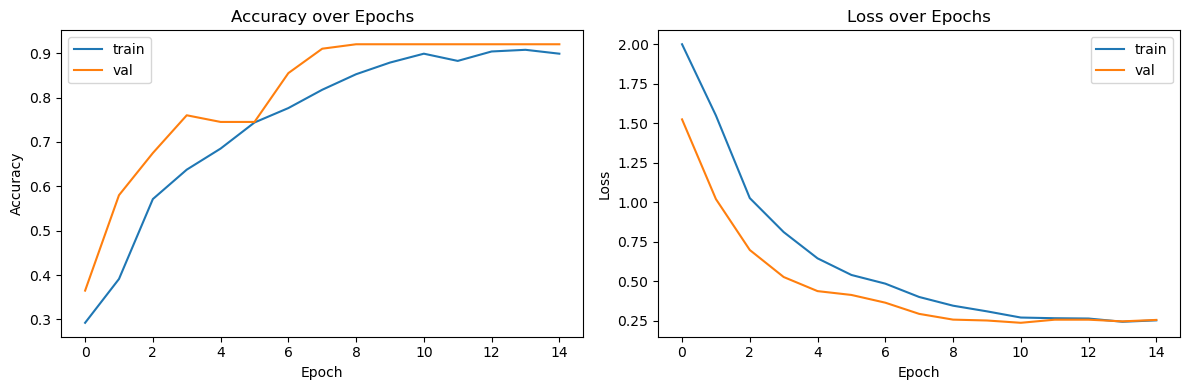

In [14]:
# Plot training history

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="train")
plt.plot(history.history["val_accuracy"], label="val")
plt.title("Accuracy over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="val")
plt.title("Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

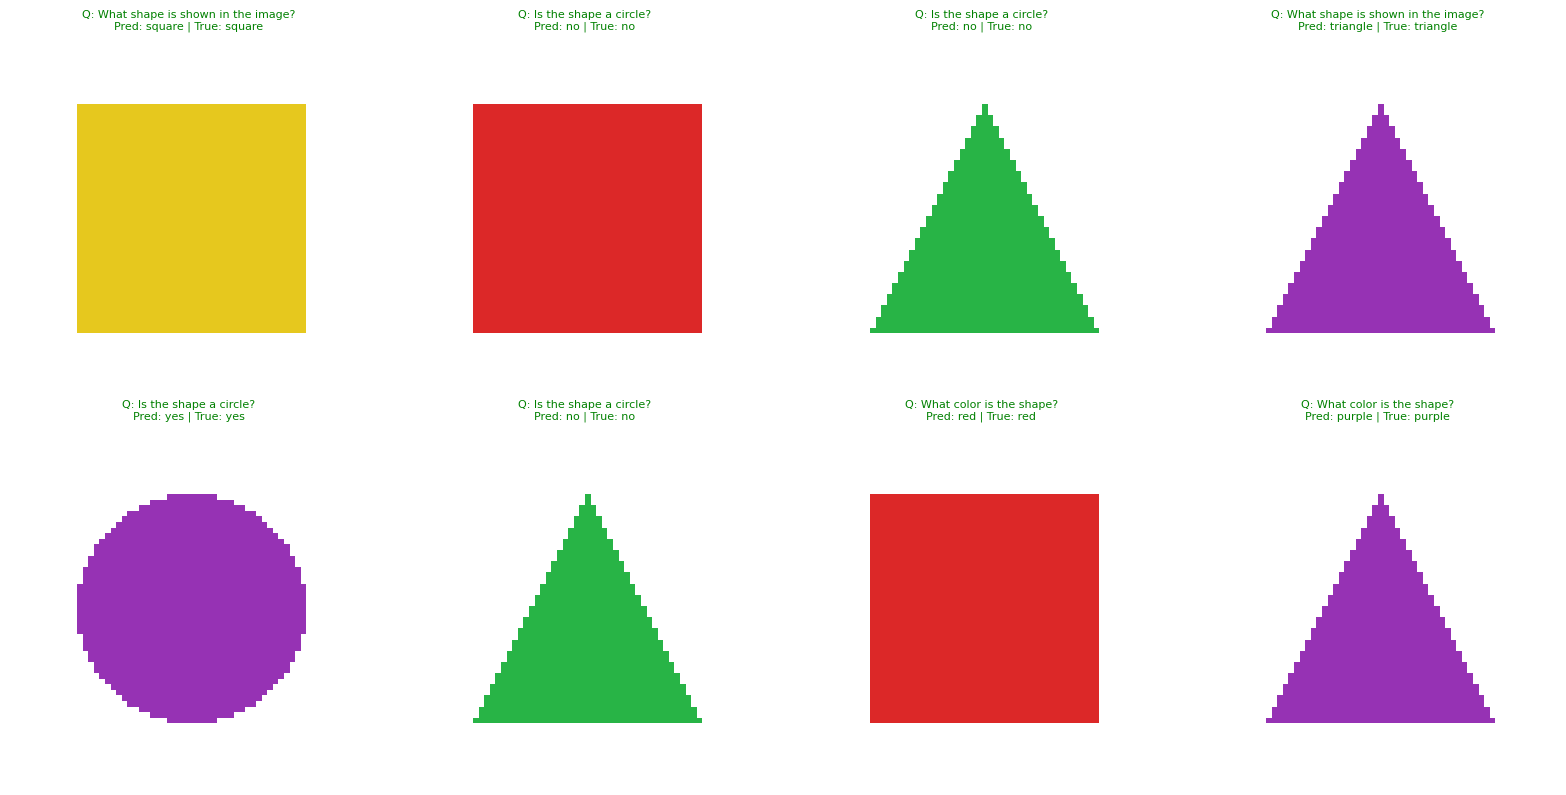

In [15]:
# Show Sample Predictions with Images

sample_indices = random.sample(range(len(Xf_test)), 8)

plt.figure(figsize=(16, 8))
for i, idx in enumerate(sample_indices):
    img_feat = Xf_test[idx : idx + 1]
    q_seq = Xq_test[idx : idx + 1]
    pred = model.predict([img_feat, q_seq], verbose=0)
    pred_label = label_encoder.inverse_transform([np.argmax(pred)])[0]
    true_label = label_encoder.inverse_transform([y_test[idx]])[0]

    # use the tracked original index to fetch the exact image + question for display
    record = records[idx_test[idx]]

    plt.subplot(2, 4, i + 1)
    plt.imshow(record["image"])
    color = "green" if pred_label == true_label else "red"
    plt.title(f"Q: {record['question']}\nPred: {pred_label} | True: {true_label}", fontsize=8, color=color)
    plt.axis("off")

plt.tight_layout()
plt.show()

# Interactive Demo

Run the cell below, provide the path to any image, type a question, and get a predicted answer.

**Note:** Since this model was trained only on synthetic colored-shape images, it will only give meaningful answers for similar shape/color questions. For real-world VQA (e.g. photos + open-ended questions), the same architecture would be trained on a real dataset like VQA v2, using a larger answer vocabulary.

In [ ]:
def predict_answer(image_path, question):
    img = Image.open(image_path).convert("RGB").resize((IMG_SIZE, IMG_SIZE))
    img_arr = np.array(img, dtype="float32")
    img_arr = preprocess_input(np.expand_dims(img_arr, axis=0))

    img_feat = cnn.predict(img_arr, verbose=0)

    seq = tokenizer.texts_to_sequences([question])
    q_seq = pad_sequences(seq, maxlen=MAX_LEN, padding="post")

    pred = model.predict([img_feat, q_seq], verbose=0)
    answer = label_encoder.inverse_transform([np.argmax(pred)])[0]

    plt.imshow(img)
    plt.title(f"Q: {question}\nPredicted Answer: {answer}")
    plt.axis("off")
    plt.show()
    return answer

# Example usage (uncomment and set your own image path):
# predict_answer("/content/my_image.png", "What color is the shape?")